# 02 - Exploratory Data Analysis (EDA)

## Goal
Understand the processed data before modelling: the shape of returns, volatility
behaviour, autocorrelation, stationarity, feature relationships, and how hard the
prediction problem is. EDA is done on the **training** split (no peeking at
val/test).

## Input
`data/processed/{train,val,test}.csv` + `metadata.json` from notebook 01.


## 0. Setup

In [14]:
from pathlib import Path

PROJECT_ROOT   = Path.cwd().parent
DATA_RAW       = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR     = PROJECT_ROOT / "models"
REPORTS_DIR    = PROJECT_ROOT / "reports"
MLRUNS_DIR     = PROJECT_ROOT / "mlruns"

for _d in (DATA_RAW, DATA_PROCESSED, MODELS_DIR, REPORTS_DIR, MLRUNS_DIR):
    _d.mkdir(parents=True, exist_ok=True)
print("Project root:", PROJECT_ROOT)

Project root: c:\Users\Użytkownik\Desktop\studia\magisterka\Machine learning\Project\MLDA - checking


In [15]:
import numpy as np
import random

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
print(f"Random seed set to {RANDOM_SEED}")

Random seed set to 42


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

## 1. Load processed data

In [17]:
df_train = pd.read_csv(DATA_PROCESSED / "train.csv", index_col=0, parse_dates=True)
df_val   = pd.read_csv(DATA_PROCESSED / "val.csv",   index_col=0, parse_dates=True)
df_test  = pd.read_csv(DATA_PROCESSED / "test.csv",  index_col=0, parse_dates=True)
with open(DATA_PROCESSED / "metadata.json") as f:
    meta = json.load(f)
FEATURE_COLS, TARGET = meta["feature_cols"], meta["target"]
print(f"Rows  train/val/test: {len(df_train)}/{len(df_val)}/{len(df_test)}")
print(f"Features: {len(FEATURE_COLS)}")
df_train[["Close", "log_return", TARGET]].describe().round(6)

Rows  train/val/test: 6121/1312/1312
Features: 25


,Close,log_return,target
count,6121.000000,6121.000000,6121.000000
mean,101425.780265,0.000034,0.504493
std,11529.759955,0.004817,0.500021
min,74724.000000,-0.050464,0.000000
25%,94144.000000,-0.001915,0.000000
50%,103572.000000,0.000038,1.000000
75%,109916.000000,0.002100,1.000000
max,123898.000000,0.049594,1.000000


## 2. Price and returns over time

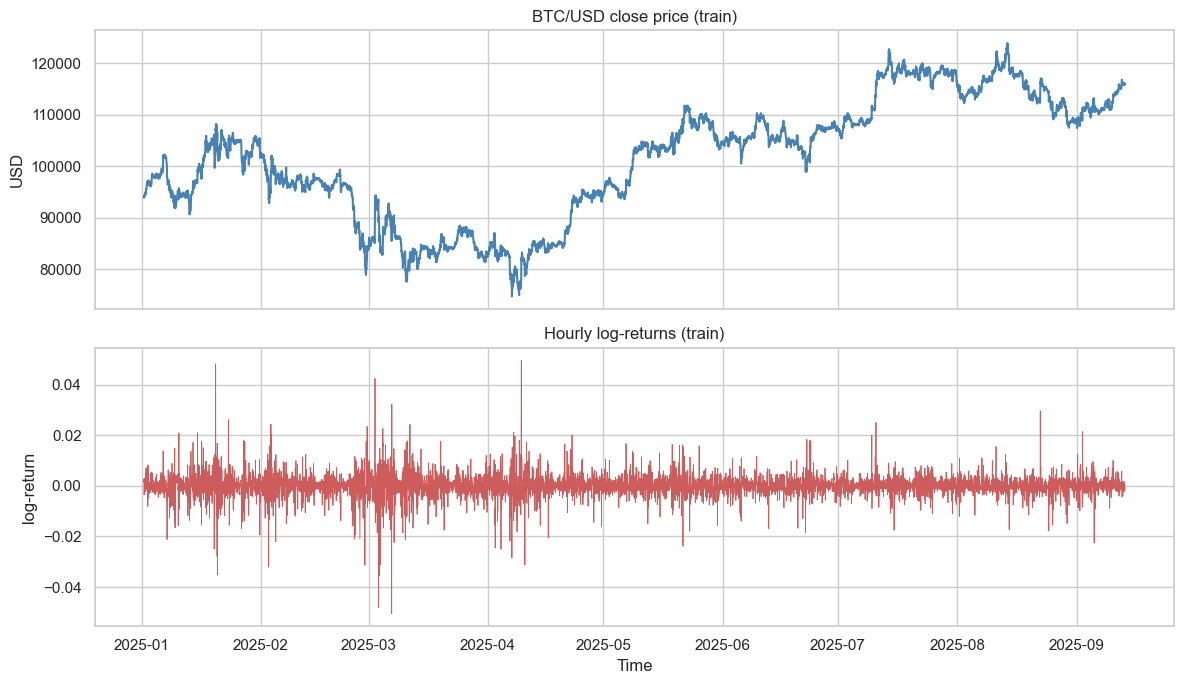

In [18]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax[0].plot(df_train.index, df_train["Close"], color="steelblue")
ax[0].set_title("BTC/USD close price (train)"); ax[0].set_ylabel("USD")
ax[1].plot(df_train.index, df_train["log_return"], color="indianred", linewidth=0.6)
ax[1].set_title("Hourly log-returns (train)"); ax[1].set_ylabel("log-return")
ax[1].set_xlabel("Time"); plt.tight_layout(); plt.show()

**Interpretation.** Over 2025, BTC/USD traded in a wide band (≈ 74.7k–126.1k USD) with a strong run-up into the autumn and a pullback over the final weeks (the slice later used for testing) - there is no single persistent trend. The hourly log-returns, by contrast, oscillate tightly around zero (mean ≈ 3.4e-5, i.e. effectively zero) with no visible drift. This is the classic near-efficient-market picture: almost all of the structure lives in the *price level*, while the *returns* we actually have to forecast look close to noise.

## 3. Distribution of returns

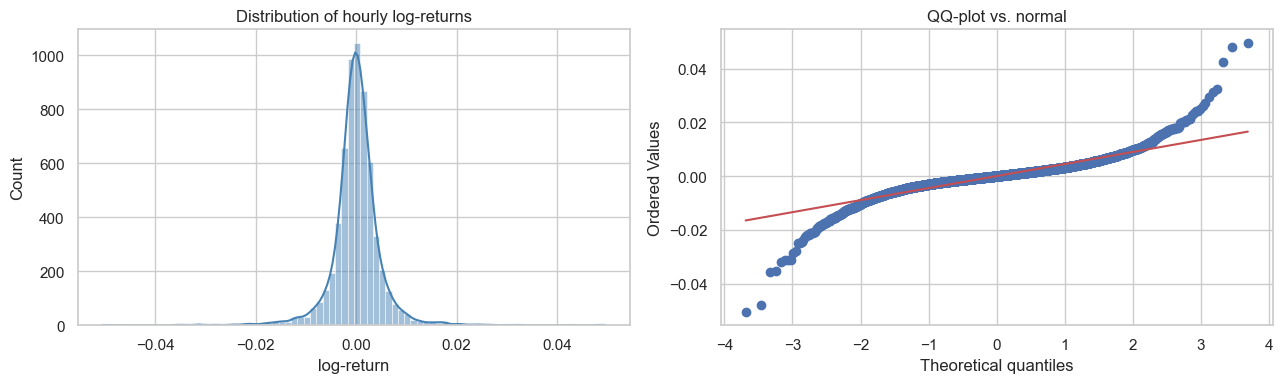

Mean 3.443e-05 | Std 4.817e-03 | Skew -0.182 | Excess kurtosis 14.240


In [19]:
from scipy import stats
r = df_train["log_return"].dropna()
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(r, bins=80, kde=True, ax=ax[0], color="steelblue")
ax[0].set_title("Distribution of hourly log-returns"); ax[0].set_xlabel("log-return")
stats.probplot(r, dist="norm", plot=ax[1])
ax[1].set_title("QQ-plot vs. normal")
plt.tight_layout(); plt.show()
print(f"Mean {r.mean():.3e} | Std {r.std():.3e} | "
      f"Skew {r.skew():.3f} | Excess kurtosis {r.kurtosis():.3f}")

**Interpretation.** The returns are sharply non-Gaussian. Excess kurtosis is ≈ 14.2 (normal = 0), so the tails are very heavy - extreme hourly moves occur far more often than a bell curve predicts - and the QQ-plot bends away from the line at both ends. Skewness is mildly negative (−0.18), so large down moves are slightly more pronounced than large up moves. This fat-tailedness is exactly why a dedicated volatility model (GARCH) and robust, non-linear learners are more appropriate here than anything assuming normal errors.

## 4. Target class balance

         train     val    test
target                        
0       0.4955  0.5023  0.4954
1       0.5045  0.4977  0.5046


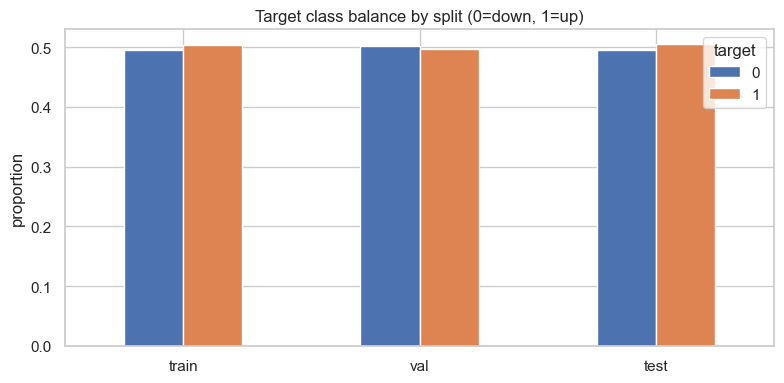

In [20]:
balance = pd.DataFrame({
    "train": df_train[TARGET].value_counts(normalize=True),
    "val":   df_val[TARGET].value_counts(normalize=True),
    "test":  df_test[TARGET].value_counts(normalize=True)}).round(4)
print(balance)
balance.T.plot(kind="bar", figsize=(8, 4), rot=0,
               title="Target class balance by split (0=down, 1=up)")
plt.ylabel("proportion"); plt.tight_layout(); plt.show()

Near 50/50 means accuracy alone is misleading — we rely on AUC / F1.

## 5. Volatility clustering

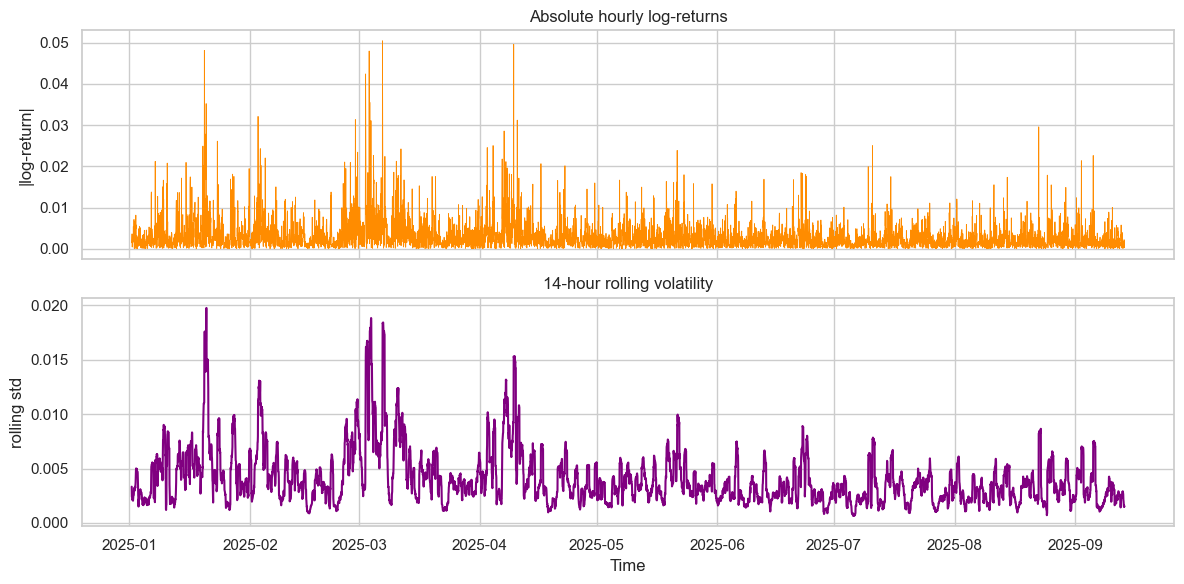

In [21]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(df_train.index, df_train["abs_log_return"], color="darkorange", linewidth=0.6)
ax[0].set_title("Absolute hourly log-returns"); ax[0].set_ylabel("|log-return|")
ax[1].plot(df_train.index, df_train["roll_std_14"], color="purple")
ax[1].set_title("14-hour rolling volatility"); ax[1].set_ylabel("rolling std")
ax[1].set_xlabel("Time"); plt.tight_layout(); plt.show()

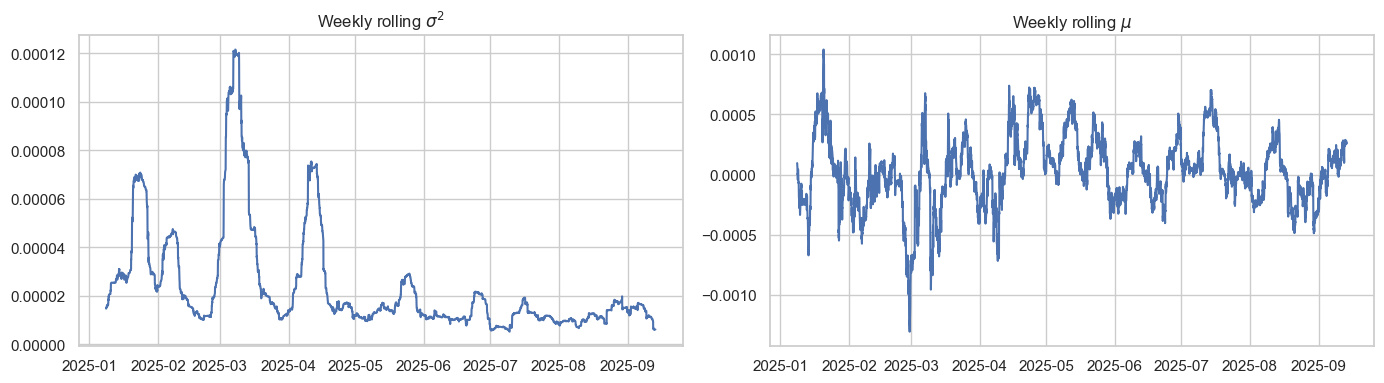

In [22]:
# Weekly window statistics make volatility clustering and drift easy to see.
weekly = 24 * 7
vol_w  = df_train["log_return"].rolling(weekly).std()
mean_w = df_train["log_return"].rolling(weekly).mean()
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(vol_w.index, vol_w.values ** 2); ax[0].set_title(r"Weekly rolling $\sigma^2$")
ax[1].plot(mean_w.index, mean_w.values);    ax[1].set_title(r"Weekly rolling $\mu$")
plt.tight_layout(); plt.show()

## 6. Autocorrelation and stationarity

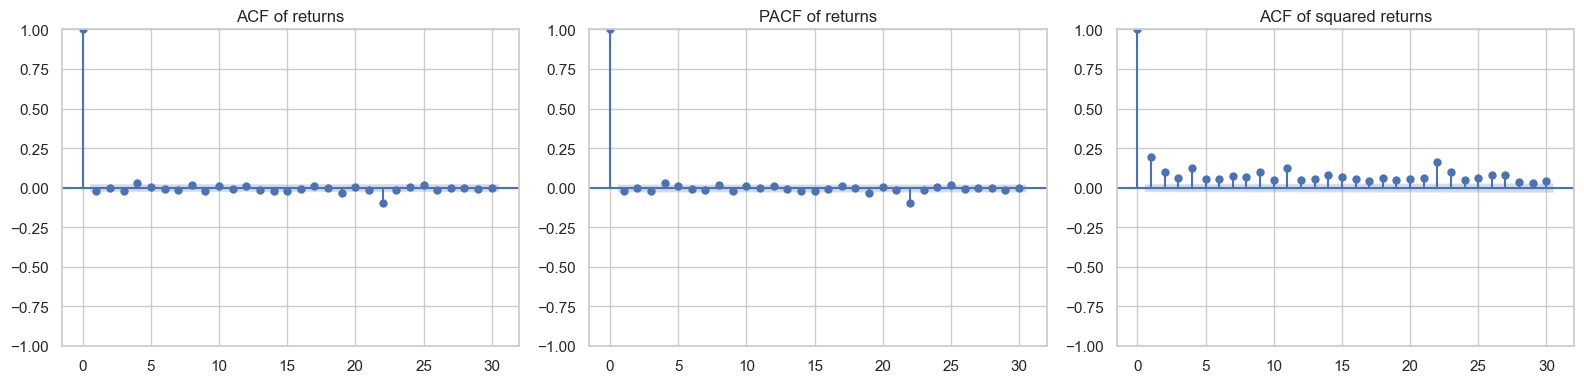

In [23]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
plot_acf(r, lags=30, ax=ax[0]);  ax[0].set_title("ACF of returns")
plot_pacf(r, lags=30, ax=ax[1], method="ywm"); ax[1].set_title("PACF of returns")
plot_acf(r**2, lags=30, ax=ax[2]); ax[2].set_title("ACF of squared returns")
plt.tight_layout(); plt.show()

In [24]:
from statsmodels.tsa.stattools import adfuller, kpss
def stationarity_report(series, name="series"):
    """Run ADF and KPSS stationarity tests and print a one-line verdict.

    Parameters
    ----------
    series : pandas.Series
        Time series to test (NaNs dropped internally).
    name : str, optional
        Label used in the printed line.

    Returns
    -------
    None
        Result is printed, not returned.
    """
    s = series.dropna()
    adf_stat, adf_p, *_ = adfuller(s)                     # H0: unit root
    kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")  # H0: stationary
    print(f"{name}: ADF p={adf_p:.4f} ({'stat.' if adf_p<0.05 else 'non-stat.'}) | "
          f"KPSS p={kpss_p:.4f} ({'non-stat.' if kpss_p<0.05 else 'stat.'})")
stationarity_report(df_train["log_return"], "train log-returns")

train log-returns: ADF p=0.0000 (stat.) | KPSS p=0.1000 (stat.)


**Interpretation.** ADF strongly rejects a unit root (p < 0.0001) and KPSS does not reject stationarity (p > 0.10); the two tests have opposite null hypotheses, so their agreement is decisive. The hourly log-returns are stationary, which justifies modelling them directly with ARIMA at differencing order **d = 0** no further differencing is needed, and the second-differencing tried in notebook 01 was unnecessary.

## 7. Feature correlations

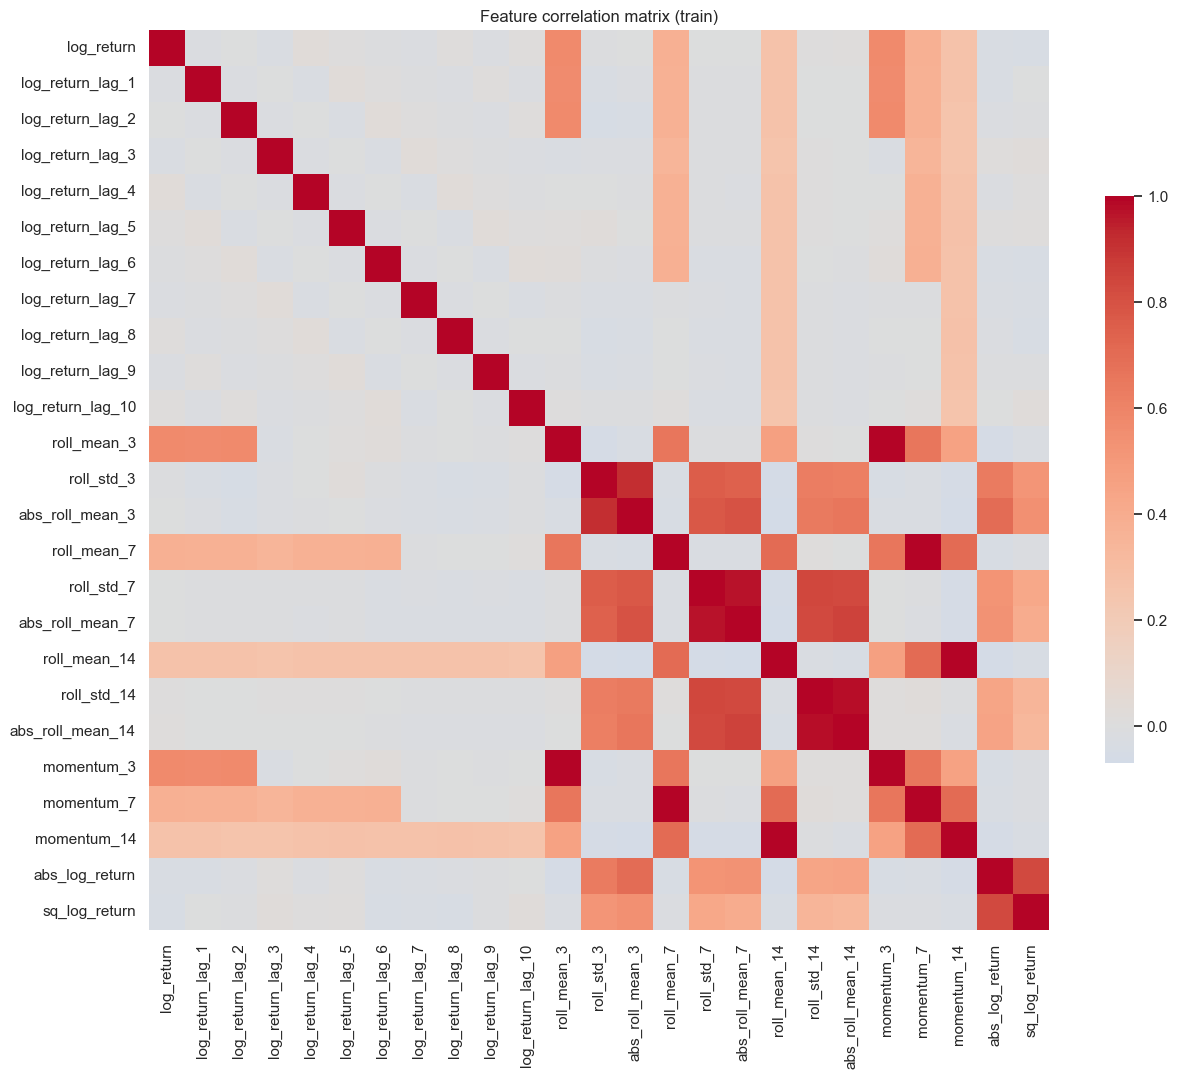

In [25]:
plt.figure(figsize=(13, 11))
sns.heatmap(df_train[FEATURE_COLS].corr(), cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.6})
plt.title("Feature correlation matrix (train)"); plt.tight_layout(); plt.show()

**Interpretation.** The heatmap shows the expected block structure. The ten lagged-return features are only weakly correlated with each other (returns carry little autocorrelation), but the rolling and momentum families form tight blocks: `roll_mean_*`, the short-window means and `momentum_*` share overlapping directional information, while `roll_std_*`, `abs_roll_mean_*` and `sq_log_return` move together as volatility proxies. This redundancy is harmless for tree ensembles, but it means only a few underlying signals - recent direction and recent volatility - are really doing the work.

## 8. Feature vs. target relationship

target              0         1
log_return   0.000229 -0.000157
roll_mean_3  0.000149 -0.000077
roll_std_3   0.003494  0.003601
momentum_3   0.000479 -0.000195
momentum_7   0.000838 -0.000176


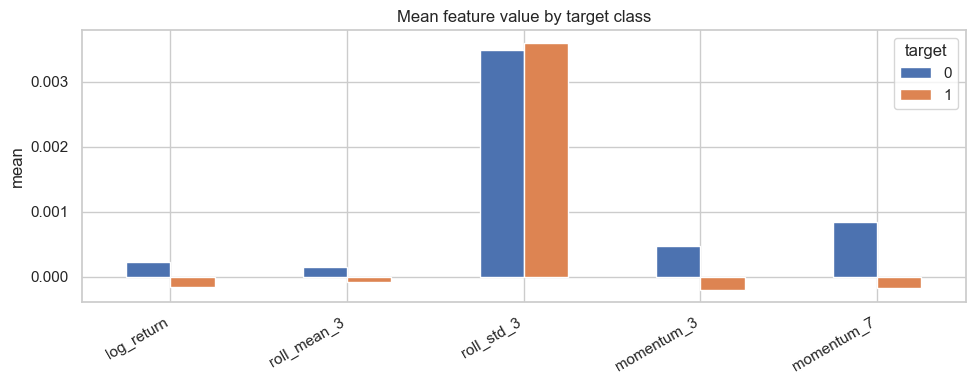

In [26]:
keys = ["log_return", "roll_mean_3", "roll_std_3", "momentum_3", "momentum_7"]
means = df_train.groupby(TARGET)[keys].mean().T
print(means.round(6))
means.plot(kind="bar", figsize=(10, 4),
           title="Mean feature value by target class")
plt.ylabel("mean"); plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()

## 9. Key takeaways

- **Returns are tiny and centred on zero** (mean ≈ 0, hourly std ≈ 0.48%): the price level moves, but the returns we must predict barely do.
- **Strongly non-Gaussian:** excess kurtosis ≈ 14 with slight negative skew - fat tails dominate, motivating GARCH and robust learners over Gaussian methods.
- **Volatility clusters:** calm and turbulent hours group together (visible in the absolute-return and rolling-σ plots and the ACF of squared returns), even though the returns themselves are nearly uncorrelated.
- **Returns are stationary:** ADF and KPSS agree, so ARIMA uses d = 0.
- **The target is balanced** (~50.4% up / 49.6% down): accuracy alone is uninformative, so we judge models by ROC-AUC and F1.
- **What little signal exists is short-horizon:** the class-conditional means point to recent return/momentum features and hint at *mean reversion* (higher recent momentum precedes slightly lower next-hour returns) - but the separation is small.
- **Low signal-to-noise overall:** this is a hard, near-efficient-market problem, so we should expect models only marginally better than chance.

-> **Next:** `03_modelling.ipynb`.